# JUPYTER ACTION CLIENT

This JupyterActionClient class implements a ROS action client in a Jupyter environment to send goals to a robot, monitor its current position and velocity, and check the distance to the nearest obstacle. It features an interactive UI using ipywidgets

In [1]:
import rospy
import actionlib
from geometry_msgs.msg import Pose, Twist
from nav_msgs.msg import Odometry
from sensor_msgs.msg import LaserScan
from assignment_2_2024.msg import PlanningAction, PlanningGoal
from assignment2.msg import PositionVelocity
from assignment2.srv import GetLastGoal
import ipywidgets as widgets
from IPython.display import display
import math

In [2]:
x_positions = []
y_positions = []
goals_reached = 0
goals_unreached = 0

##  Initialization

When the class is instantiated, it:
- Initializes a ROS node for communication.
- Connects to a ROS **action server** (`/reaching_goal`) that handles goal-based navigation tasks.
- Sets up a **publisher** to send custom messages containing the robot’s current position and velocity.
- Subscribes to two key topics:
  - `/odom` for odometry data (position and velocity)
  - `/scan` for laser scan data (distance to obstacles)

## Widget-Based UI

The class uses Jupyter widgets to build a simple user interface:
- **FloatText fields** to enter X and Y coordinates for the navigation goal.
- **Buttons** to send or cancel goals.
- **Labels** to display:
  - The robot's current position
  - The distance to the nearest obstacle

In [3]:
class JupyterActionClient:
    def __init__(self):
        rospy.init_node('jupyter_action_client', anonymous=True)

        self.client = actionlib.SimpleActionClient('/reaching_goal', PlanningAction)
        self.client.wait_for_server()
        rospy.loginfo("Action server ready!")

        self.pub_position_velocity = rospy.Publisher('/position_velocity', PositionVelocity, queue_size=10)

        self.current_pose = Pose()
        self.current_velocity = Twist()
        self.closest_obstacle_distance = math.inf  # Initially infinite

        self.x_goal = widgets.FloatText(description='X Goal:')
        self.y_goal = widgets.FloatText(description='Y Goal:')
        self.send_button = widgets.Button(description='Send Goal', button_style='success')
        self.cancel_button = widgets.Button(description='Cancel Goal', button_style='danger')
        self.position_label = widgets.Label(value="Current Position: x=0.0, y=0.0")
        self.distance_label = widgets.Label(value="Distance to Closest Obstacle: ∞")
        self.output = widgets.Output()

        self.send_button.on_click(self.send_goal)
        self.cancel_button.on_click(self.cancel_goal)

        self.ui = widgets.VBox([
            widgets.HBox([self.x_goal, self.y_goal]),
            widgets.HBox([self.send_button, self.cancel_button]),
            self.position_label,
            self.distance_label,
            self.output
        ])

        display(self.ui)

        self.sub_odom = rospy.Subscriber('/odom', Odometry, self.odom_callback)
        self.sub_scan = rospy.Subscriber('/scan', LaserScan, self.scan_callback)

    def odom_callback(self, msg):
        global x_positions, y_positions
        self.current_pose = msg.pose.pose
        self.current_velocity = msg.twist.twist

        x_positions.append(self.current_pose.position.x)
        y_positions.append(self.current_pose.position.y)

        custom_msg = PositionVelocity()
        custom_msg.x = self.current_pose.position.x
        custom_msg.y = self.current_pose.position.y
        custom_msg.vel_x = self.current_velocity.linear.x
        custom_msg.vel_z = self.current_velocity.angular.z
        self.pub_position_velocity.publish(custom_msg)

        self.update_position()

    def scan_callback(self, msg):
        if len(msg.ranges) > 0:
            valid_ranges = [d for d in msg.ranges if not math.isinf(d)]
            if valid_ranges:
                self.closest_obstacle_distance = min(valid_ranges)
            else:
                self.closest_obstacle_distance = math.inf
            self.update_distance()

    def update_position(self):
        x = self.current_pose.position.x
        y = self.current_pose.position.y
        self.position_label.value = f"Current Position: x = {x:.2f}, y = {y:.2f}"

    def update_distance(self):
        if self.closest_obstacle_distance != math.inf:
            self.distance_label.value = f"Distance to Closest Obstacle: {self.closest_obstacle_distance:.2f} m"
        else:
            self.distance_label.value = "Distance to Closest Obstacle: ∞"

    def send_goal(self, b):
        global goals_reached, goals_unreached

        goal = PlanningGoal()
        goal.target_pose.pose.position.x = self.x_goal.value
        goal.target_pose.pose.position.y = self.y_goal.value

        def done_cb(state, result):
            global goals_reached, goals_unreached
            if state == 3:  # SUCCEEDED
                goals_reached += 1
            else:
                goals_unreached += 1

        self.client.send_goal(goal, done_cb=done_cb)
        rospy.loginfo(f"Sent goal: x = {self.x_goal.value}, y = {self.y_goal.value}")

    def cancel_goal(self, b):
        self.client.cancel_goal()
        rospy.loginfo("Goal canceled")

## 🎯 Goal Management

When the **"Send Goal"** button is clicked:
- A new goal is sent to the action server using the provided X and Y coordinates.
- A callback function monitors whether the goal is reached or not, updating success/failure counters accordingly.

When the **"Cancel Goal"** button is clicked:
- The currently active goal is canceled.

In [4]:
client = JupyterActionClient()

[INFO] [1747067862.081491, 1791.073000]: Action server ready!


[INFO] [1747067871.158081, 1799.366000]: Sent goal: x = 1.0, y = 1.0


##  Visualization: Robot Path and Goal Statistics

The following animation displays two visual elements in real-time:

###  1. Robot Path (Left Plot)
- The left subplot shows the path followed by the robot using the list of positions:
  - `x_positions`: list of x-coordinates
  - `y_positions`: list of y-coordinates
- This data is updated live through the `/odom` topic in the `odom_callback` method of `JupyterActionClient`.
- The path is plotted with blue dots connected by lines, representing the movement trajectory over time.

###  2. Goal Statistics (Right Plot)
- The right subplot is a bar chart displaying how many goals have been:
  - ✅ **Reached**
  - ❌ **Unreached**
- These counters (`goals_reached`, `goals_unreached`) are updated in the `send_goal` method via the result callback.

###  Animation Loop
- The `animate(i)` function is called every 1000 milliseconds (1 second) using `FuncAnimation`.
- It clears both subplots, redraws the path and the goal status to reflect the most current state.


<IPython.core.display.Javascript object>


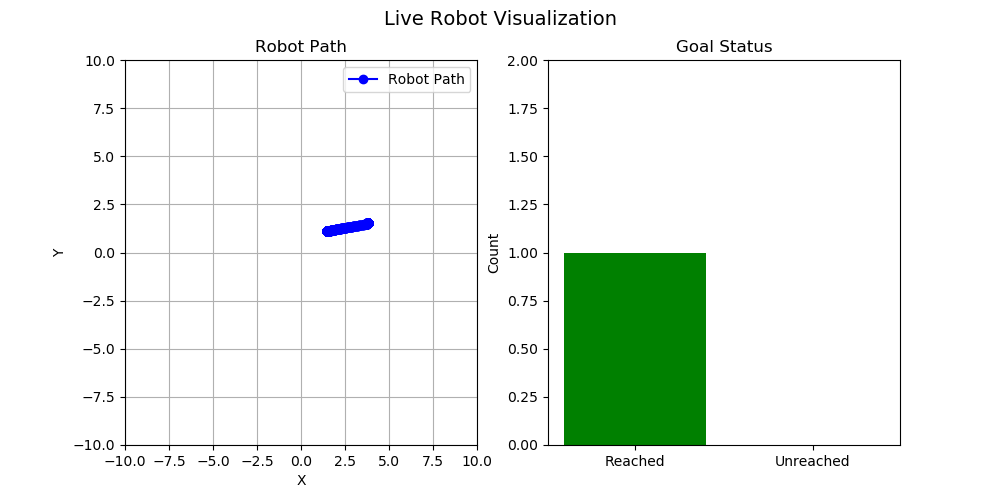

In [5]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display
import ipywidgets as widgets

%matplotlib notebook

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

fig.suptitle("Live Robot Visualization", fontsize=14)
ax1.set_title("Robot Path")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.grid(True)
ax1.legend(loc="upper right")

ax2.set_title("Goal Status")
ax2.set_ylabel("Count")

def animate(i):
    ax1.clear()
    ax2.clear()

    ax1.plot(x_positions, y_positions, 'bo-', label="Robot Path")
    ax1.set_xlim(-10, 10)
    ax1.set_ylim(-10, 10)
    ax1.set_title("Robot Path")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.grid(True)
    ax1.legend()

    ax2.bar(['Reached', 'Unreached'], [goals_reached, goals_unreached], color=['green', 'red'])
    ax2.set_title("Goal Status")
    ax2.set_ylabel("Count")
    ax2.set_ylim(0, max(goals_reached, goals_unreached, 1) + 1)

ani = FuncAnimation(fig, animate, interval=1000)

#display(fig)
